## ***ML Training & SHAP Explainability***

### ***Install & Imports***

In [1]:
!pip install shap azure-storage-blob -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 10.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 14.4 MB/s eta 0:00:00


In [33]:
import json
import os
import pickle
import warnings
from pathlib import Path
from kaggle_secrets import UserSecretsClient
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image, display

warnings.filterwarnings("ignore")

### ***Config***

In [3]:
secrets = UserSecretsClient()
os.environ["AZURE_STORAGE_CONN_STR"] = secrets.get_secret("AZURE_STORAGE_CONN_STR")
os.environ["AZURE_CONTAINER"]        = secrets.get_secret("AZURE_CONTAINER")

In [4]:
MODEL_DIR = Path("/kaggle/working/models")
PLOT_DIR = Path("/kaggle/working/plots")
DATA_DIR = Path("/kaggle/working/data")
for d in [MODEL_DIR, PLOT_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

### ***Azure Blob Helpers***

In [5]:
def load_from_azure(filename: str):
    from azure.storage.blob import BlobServiceClient
    conn_str = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    return json.loads(container.download_blob(f"notebook_data/{filename}").readall())

In [6]:
def save_bytes_to_azure(data: bytes, filename: str):
    """Upload raw bytes (e.g. pickle files) to Azure Blob Storage."""
    from azure.storage.blob import BlobServiceClient
    conn_str = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    container.upload_blob(name=f"models/{filename}", data=data, overwrite=True)
    print(f"[Azure] Saved → models/{filename}")

In [7]:
def save_json_to_azure(data, filename: str):
    from azure.storage.blob import BlobServiceClient
    conn_str = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    container.upload_blob(name=f"models/{filename}", data=json.dumps(data), overwrite=True)
    print(f"[Azure] Saved → models/{filename}")

In [8]:
raw_stream = load_from_azure("raw_stream.json")
df_raw = pd.DataFrame(raw_stream)
df_raw["open_time"] = pd.to_numeric(df_raw["open_time"])
df_raw = df_raw.sort_values(["symbol", "open_time"]).reset_index(drop=True)

for c in ["open","high","low","close","volume","quote_volume","trade_count",
          "price_change_pct_24h","volume_24h","quote_volume_24h"]:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce").fillna(0)

print(f"Loaded {len(df_raw):,} candles across {df_raw['symbol'].nunique()} symbols")
print(f"Date range: {df_raw['timestamp'].min()[:10]} → {df_raw['timestamp'].max()[:10]}")

Loaded 32,650 candles across 20 symbols
Date range: 2026-02-24 → 2026-02-26


### ***Feature Engineering***

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Generate 30+ features per candle from OHLCV data. No look-ahead."""
    result = []
    for symbol, grp in df.groupby("symbol"):
        g = grp.copy().sort_values("open_time").reset_index(drop=True)
        c = g["close"].astype(float)
        o = g["open"].astype(float)
        h = g["high"].astype(float)
        l = g["low"].astype(float)
        v = g["volume"].astype(float)

        # Candle anatomy
        g["candle_body"] = abs(c - o)
        g["candle_range"] = h - l
        g["upper_wick"] = h - pd.concat([o, c], axis=1).max(axis=1)
        g["lower_wick"] = pd.concat([o, c], axis=1).min(axis=1) - l
        g["body_ratio"] = g["candle_body"] / g["candle_range"].replace(0, np.nan)
        g["is_bullish"] = (c > o).astype(int)

        # Price momentum
        g["pct_change_1h"] = c.pct_change(1) * 100
        g["pct_change_3h"] = c.pct_change(3) * 100
        g["pct_change_6h"] = c.pct_change(6) * 100
        g["pct_change_24h"] = c.pct_change(24) * 100

        # Moving averages & deviation
        for w in [6, 12, 24, 48]:
            sma = c.rolling(w, min_periods=1).mean()
            g[f"sma_{w}"] = sma
            g[f"price_vs_sma_{w}"] = (c - sma) / sma.replace(0, np.nan) * 100

        # MACD
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        g["macd"] = ema12 - ema26
        g["macd_signal"] = g["macd"].ewm(span=9, adjust=False).mean()
        g["macd_hist"] = g["macd"] - g["macd_signal"]

        # Volatility
        log_ret = np.log(c / c.shift(1).replace(0, np.nan))
        g["volatility_6h"] = log_ret.rolling(6,  min_periods=2).std()
        g["volatility_24h"] = log_ret.rolling(24, min_periods=2).std()

        # Bollinger Bands
        sma20 = c.rolling(20, min_periods=1).mean()
        std20 = c.rolling(20, min_periods=2).std().fillna(0)
        g["bb_upper"] = sma20 + 2 * std20
        g["bb_lower"] = sma20 - 2 * std20
        g["bb_width"] = (g["bb_upper"] - g["bb_lower"]) / sma20.replace(0, np.nan)
        g["bb_pct"] = (c - g["bb_lower"]) / (g["bb_upper"] - g["bb_lower"]).replace(0, np.nan)

        # RSI
        delta = c.diff()
        gain = delta.clip(lower=0).rolling(14, min_periods=1).mean()
        loss = (-delta.clip(upper=0)).rolling(14, min_periods=1).mean()
        g["rsi"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

        # Volume
        vol_sma24 = v.rolling(24, min_periods=1).mean()
        g["vol_change"] = v.pct_change(1) * 100
        g["vol_ratio"] = v / vol_sma24.replace(0, np.nan)
        obv = (np.sign(c.diff()) * v).fillna(0).cumsum()
        obv_max = obv.abs().max()
        g["obv_norm"] = obv / obv_max if obv_max > 0 else 0

        # Liquidity
        g["liquidity_ratio"] = v / g["volume_24h"].replace(0, np.nan) if "volume_24h" in g else 0
        g["mcap_log"] = 0   # market cap not available from Kraken

        # Targets
        g["next_close"] = c.shift(-1)
        g["target_direction"] = (g["next_close"] > c).astype(int)
        g["target_pct"] = (g["next_close"] - c) / c.replace(0, np.nan) * 100

        result.append(g)

    df_feat = pd.concat(result, ignore_index=True)
    df_feat = df_feat.dropna(subset=["next_close", "target_pct"])
    print(f"Features engineered: {df_feat.shape[1]} columns, {len(df_feat):,} rows")
    return df_feat

In [10]:
df_feat = engineer_features(df_raw)

Features engineered: 59 columns, 32,630 rows


### ***Train Test Split*** 

In [11]:
FEATURE_COLS = [
    "candle_body", "candle_range", "upper_wick", "lower_wick", "body_ratio", "is_bullish",
    "pct_change_1h", "pct_change_3h", "pct_change_6h", "pct_change_24h",
    "price_vs_sma_6", "price_vs_sma_12", "price_vs_sma_24", "price_vs_sma_48",
    "macd", "macd_signal", "macd_hist",
    "volatility_6h", "volatility_24h",
    "bb_width", "bb_pct",
    "rsi",
    "vol_change", "vol_ratio", "obv_norm",
    "liquidity_ratio", "mcap_log",
]

In [12]:
available = [c for c in FEATURE_COLS if c in df_feat.columns]
print(f"Using {len(available)} features")

Using 27 features


In [13]:
df_model = df_feat[available + ["target_direction", "target_pct"]].dropna()
print(f"Model dataset: {len(df_model):,} rows")
print(f"Class balance: {df_model['target_direction'].value_counts().to_dict()}")

Model dataset: 30,730 rows
Class balance: {0: 19161, 1: 11569}


In [14]:
X = df_model[available].values
y_cls = df_model["target_direction"].values
y_reg = df_model["target_pct"].values

In [15]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

In [16]:
scaler    = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 24,584  |  Test: 6,146


### ***Model Training***  

In [17]:
# Random Forest Classifier
clf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1,
)
clf.fit(X_train_s, y_cls_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [18]:
# Random Forest Regressor
reg = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_leaf=5,
    max_features="sqrt", random_state=42, n_jobs=-1,
)
reg.fit(X_train_s, y_reg_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

### ***Evaluation***  

In [19]:
y_pred_cls  = clf.predict(X_test_s)
y_pred_prob = clf.predict_proba(X_test_s)[:, 1]
y_pred_reg  = reg.predict(X_test_s)

In [20]:
print("CLASSIFIER — Price Direction (UP / DOWN)")
print(classification_report(y_cls_test, y_pred_cls, target_names=["DOWN", "UP"]))
auc = roc_auc_score(y_cls_test, y_pred_prob)
acc = accuracy_score(y_cls_test, y_pred_cls)
print(f"ROC-AUC:  {auc:.4f}")
print(f"Accuracy: {acc:.4f}")

CLASSIFIER — Price Direction (UP / DOWN)
              precision    recall  f1-score   support

        DOWN       0.70      0.70      0.70      3832
          UP       0.50      0.49      0.50      2314

    accuracy                           0.62      6146
   macro avg       0.60      0.60      0.60      6146
weighted avg       0.62      0.62      0.62      6146

ROC-AUC:  0.6488
Accuracy: 0.6237


In [21]:
cv_auc = cross_val_score(clf, X_train_s, y_cls_train, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-Fold CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

5-Fold CV AUC: 0.6578 ± 0.0087


In [22]:
print("REGRESSOR — % Change Magnitude")
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = mean_squared_error(y_reg_test, y_pred_reg) ** 0.5
r2   = r2_score(y_reg_test, y_pred_reg)
print(f"MAE:  {mae:.4f}%")
print(f"RMSE: {rmse:.4f}%")
print(f"R²:   {r2:.4f}")

REGRESSOR — % Change Magnitude
MAE:  0.1758%
RMSE: 0.3316%
R²:   0.0903


### ***SHAP Explainability***

In [32]:
N_SHAP = min(500, len(X_test_s))
shap_idx = np.random.choice(len(X_test_s), N_SHAP, replace=False)
X_shap = X_test_s[shap_idx]
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(X_shap)

# Handle both old (list) and new (3D array) shap versions
if isinstance(sv, list):
    sv_2d = sv[1]                        # old: list of [class0, class1]
elif sv.ndim == 3:
    sv_2d = sv[:, :, 1]                  # new: (samples, features, classes)
else:
    sv_2d = sv                           # already 2D

print(f"SHAP values computed for {N_SHAP} samples | shape: {sv_2d.shape}")

# Summary bar
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_2d, X_shap, feature_names=available, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP|)", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / "shap_1_summary_bar.png", dpi=150, bbox_inches="tight")
plt.close()

# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_2d, X_shap, feature_names=available, show=False)
plt.title("SHAP Beeswarm — Feature Impact on UP Probability", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / "shap_2_beeswarm.png", dpi=150, bbox_inches="tight")
plt.close()

# Waterfall
try:
    shap_exp = explainer(X_shap)
    exp_to_plot = shap_exp[:, :, 1] if shap_exp.values.ndim == 3 else shap_exp
    shap.plots.waterfall(exp_to_plot[0], max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "shap_3_waterfall.png", dpi=150, bbox_inches="tight")
    plt.close()
except Exception as e:
    print(f"[WARN] Waterfall: {e}")

# Dependence (top 2 features)
mean_abs = np.abs(sv_2d).mean(axis=0)
top2 = [int(np.argsort(mean_abs)[-1]), int(np.argsort(mean_abs)[-2])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fi in zip(axes, top2):
    ax.scatter(X_shap[:, fi], sv_2d[:, fi], alpha=0.4, s=10)
    ax.set_xlabel(available[fi])
    ax.set_ylabel(f"SHAP value for {available[fi]}")
    ax.set_title(f"SHAP Dependence: {available[fi]}")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig(PLOT_DIR / "shap_4_dependence.png", dpi=150, bbox_inches="tight")
plt.close()

SHAP values computed for 500 samples | shape: (500, 27)


shap_1_summary_bar.png


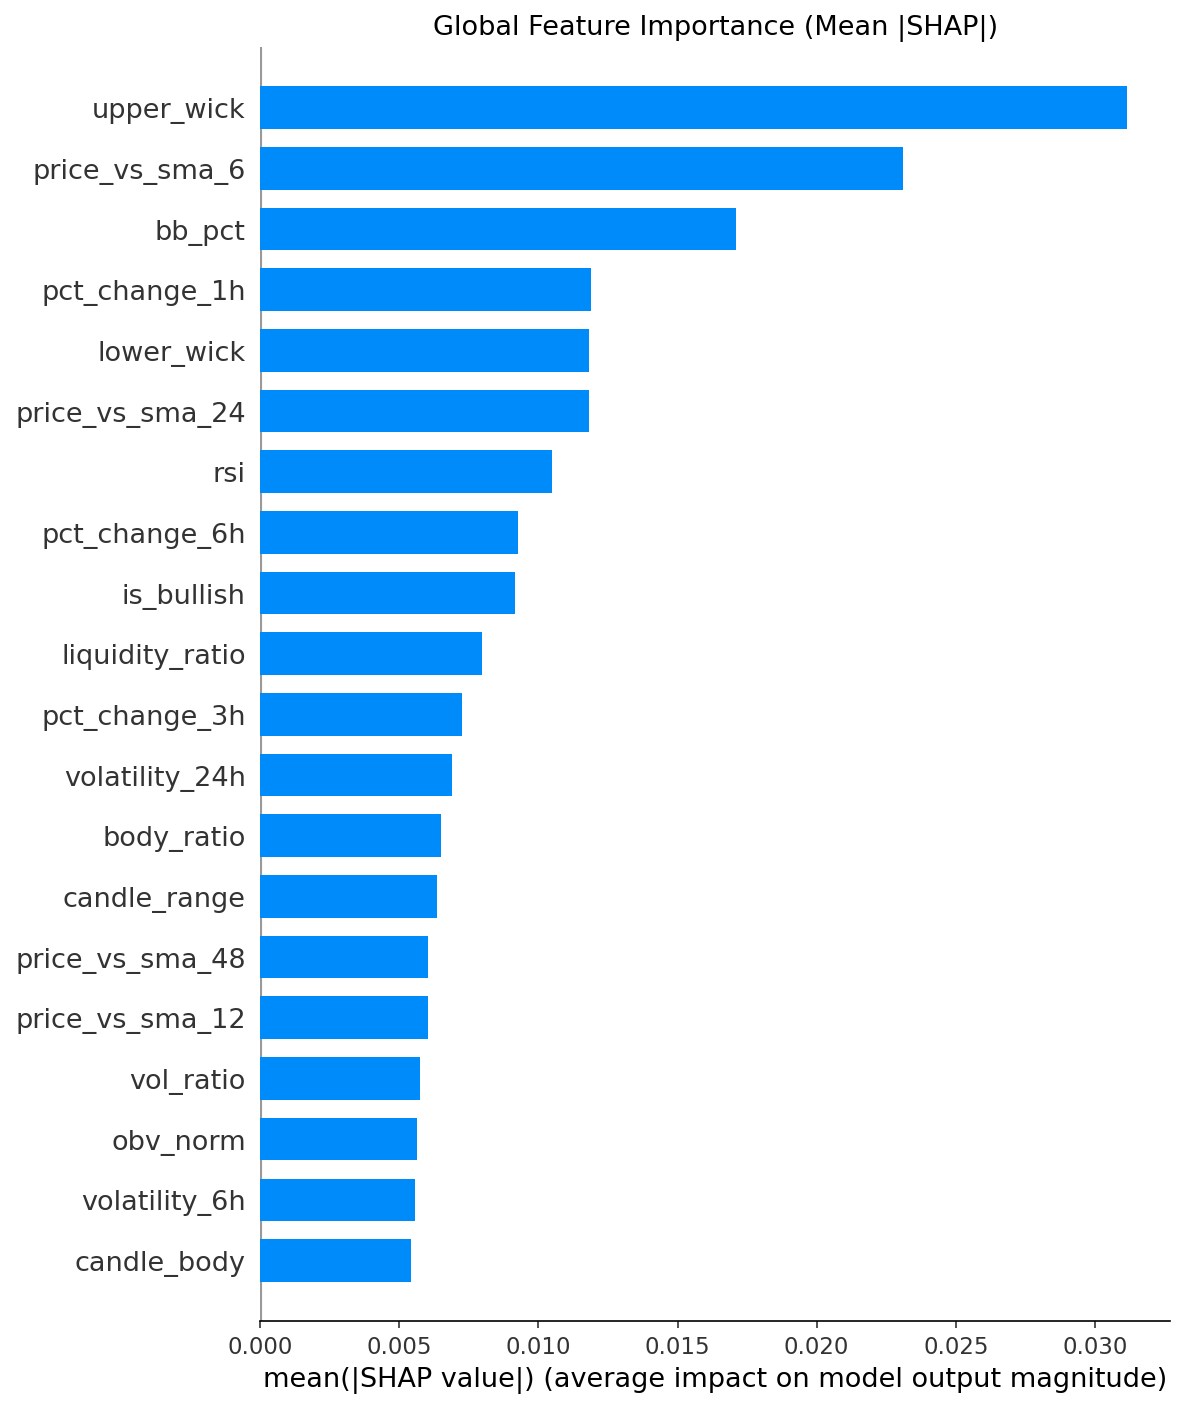

shap_2_beeswarm.png


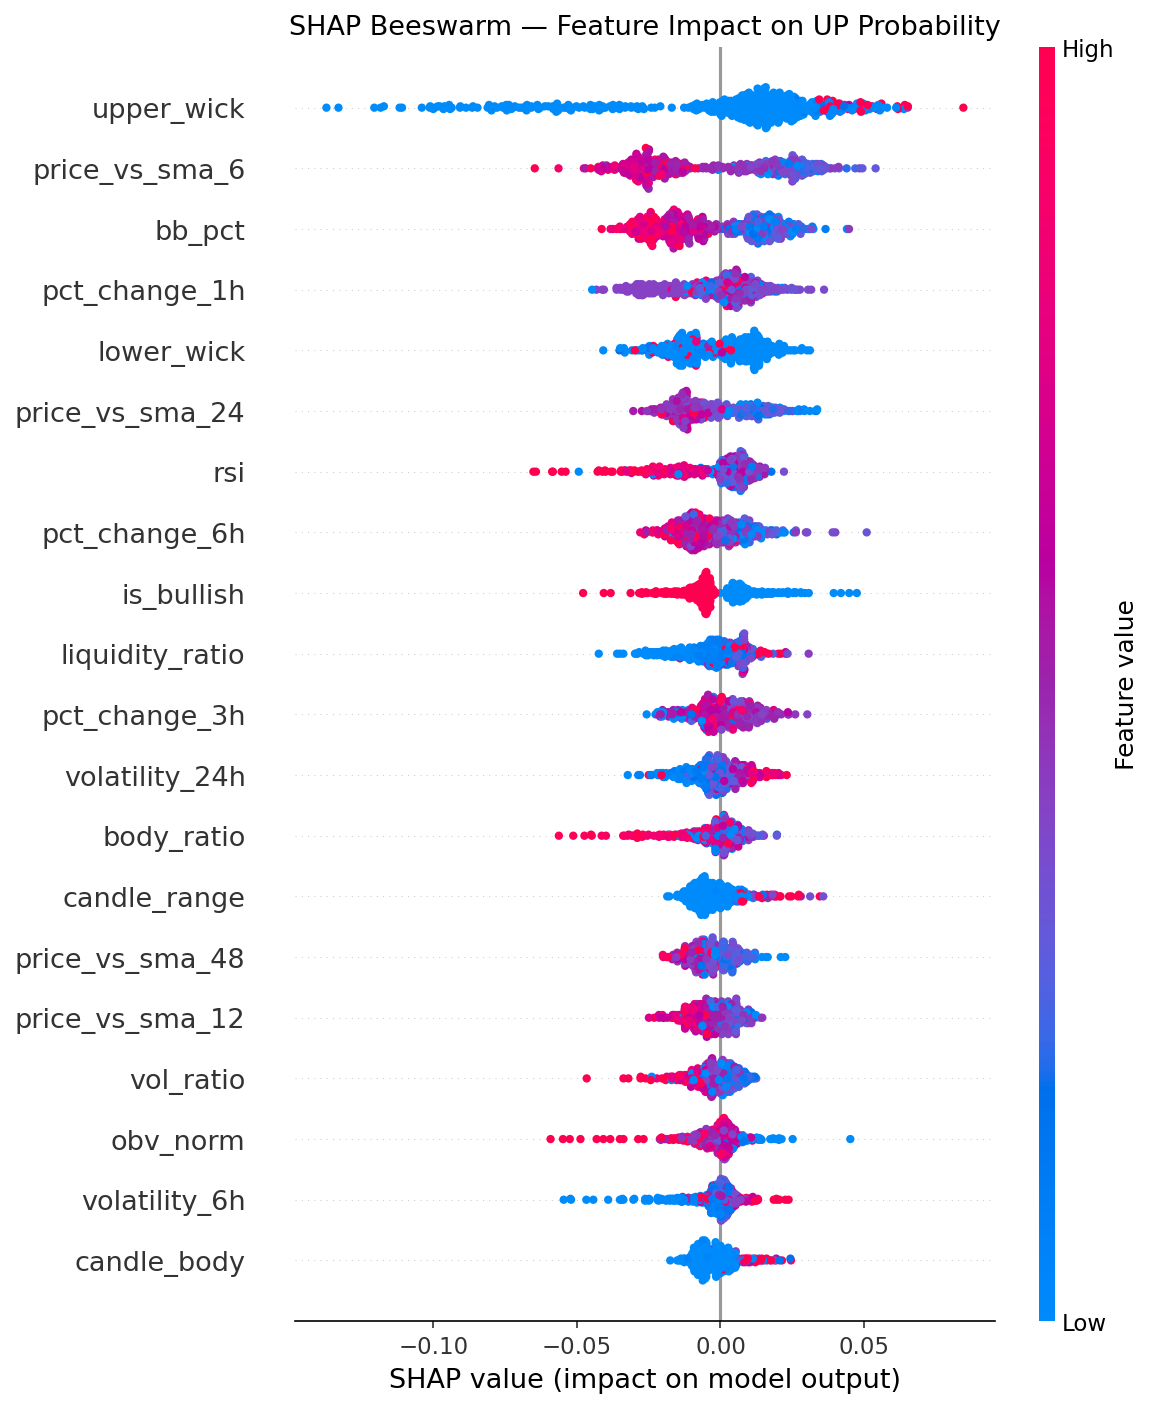

shap_3_waterfall.png


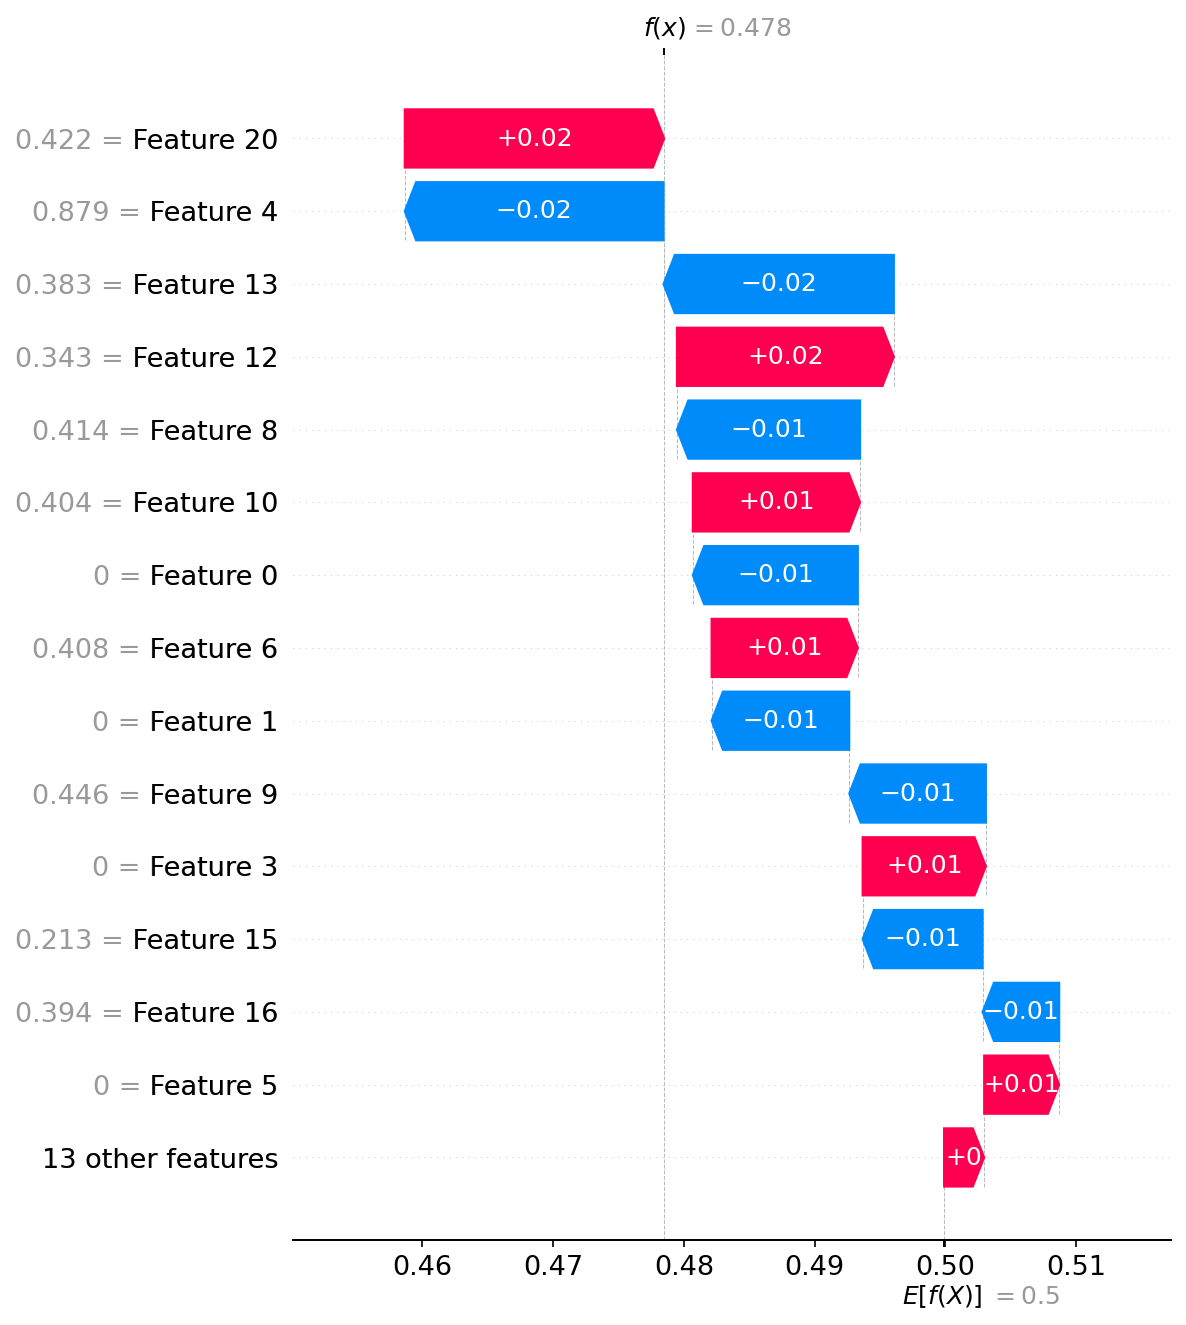

shap_4_dependence.png


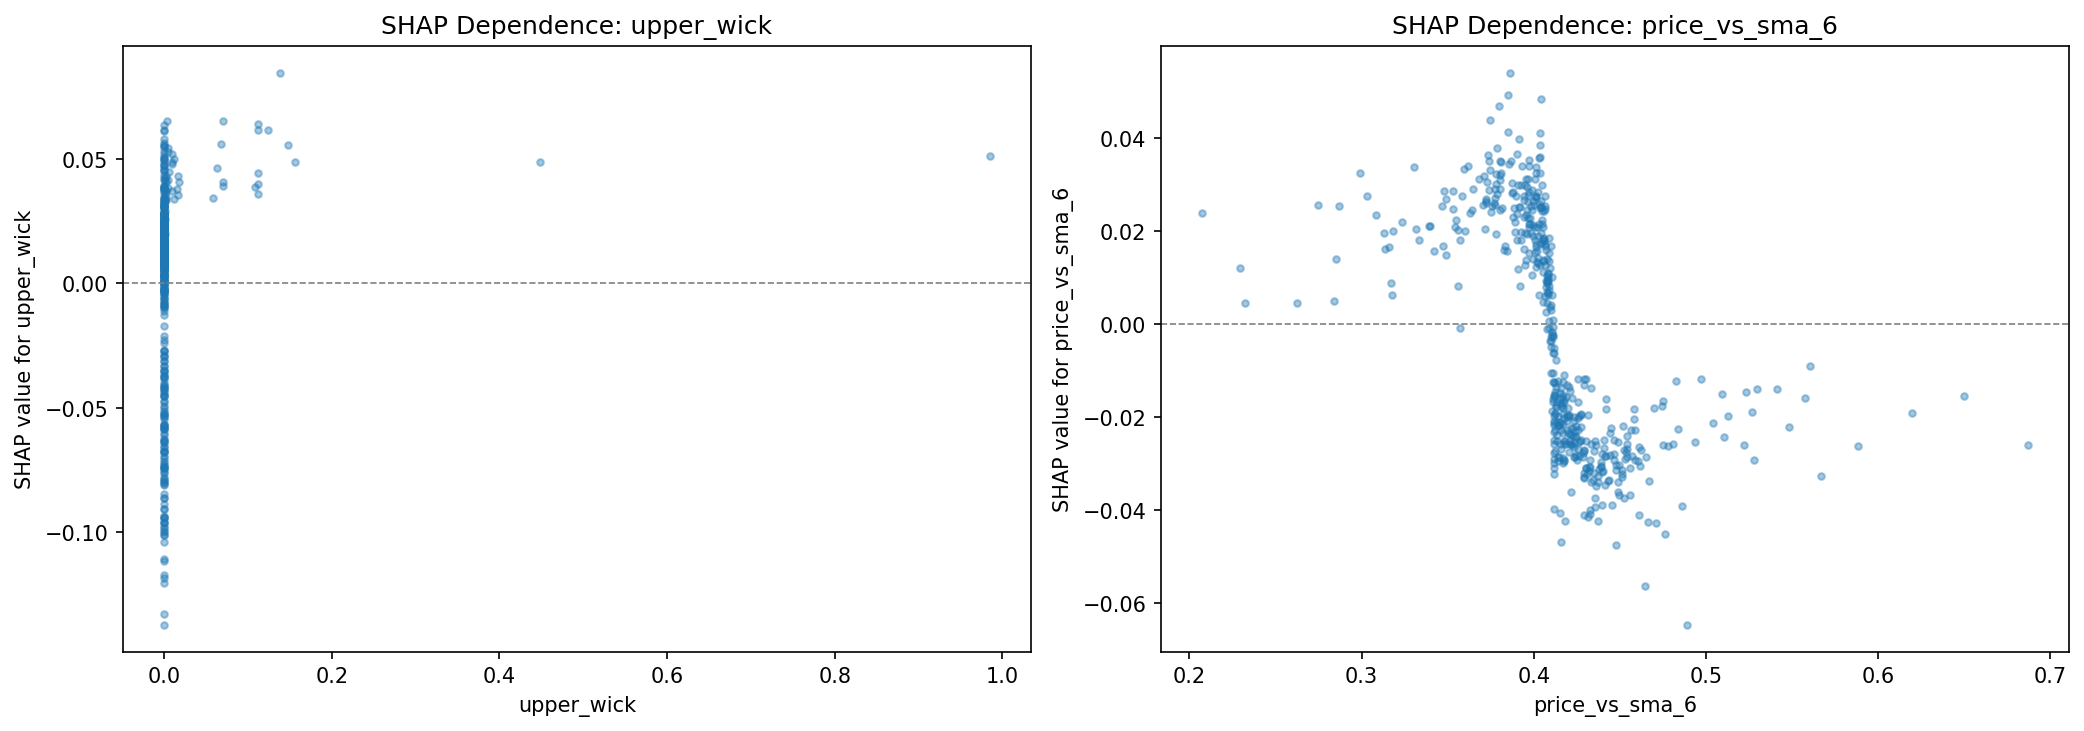

In [34]:
for fname in ["shap_1_summary_bar.png", "shap_2_beeswarm.png", "shap_3_waterfall.png", "shap_4_dependence.png"]:
    fpath = PLOT_DIR / fname
    if fpath.exists():
        print(fname)
        display(Image(filename=str(fpath)))

### ***Diagnostic Plots***

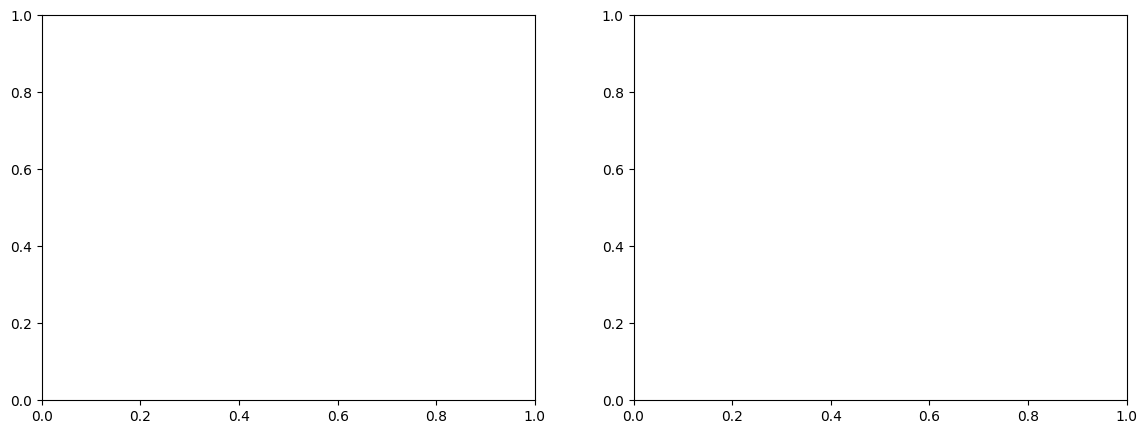

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

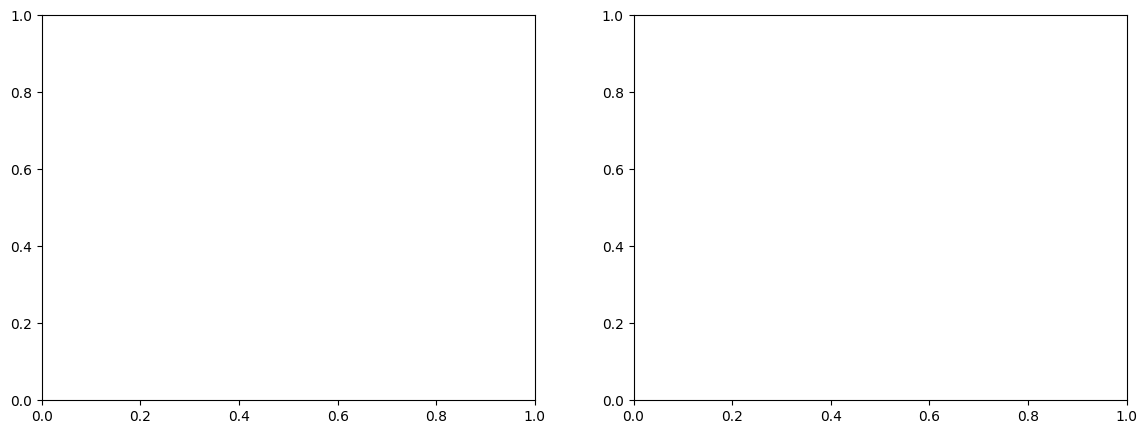

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

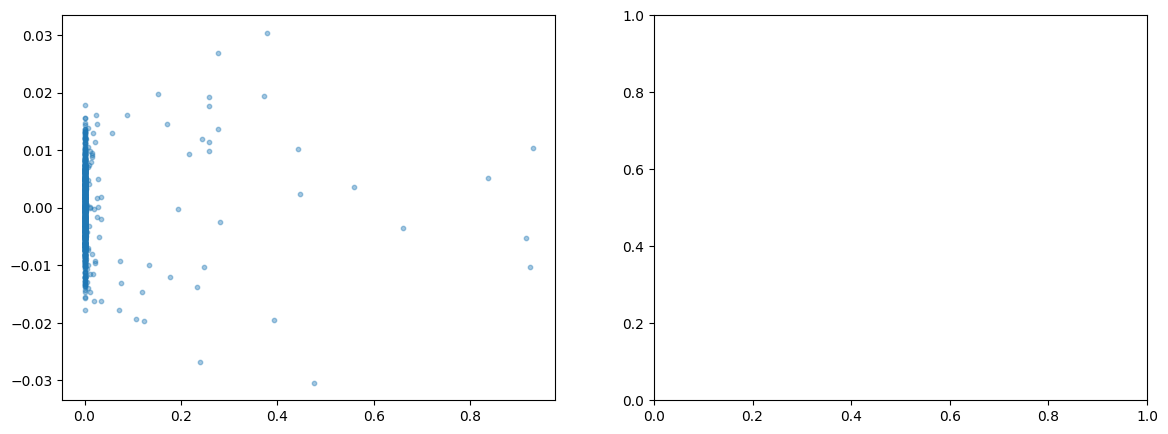

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

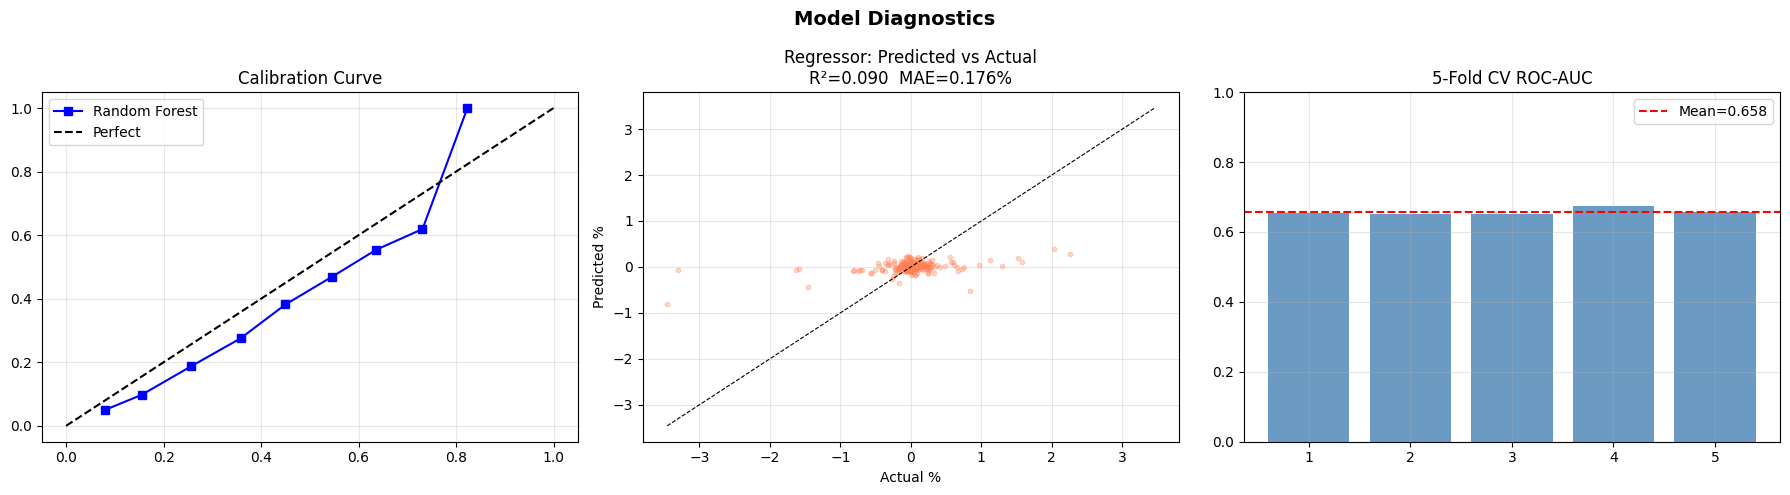

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Diagnostics", fontsize=14, fontweight="bold")

ax = axes[0]
prob_true, prob_pred = calibration_curve(y_cls_test, y_pred_prob, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", color="blue", label="Random Forest")
ax.plot([0,1], [0,1], "k--", label="Perfect")
ax.set_title("Calibration Curve"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_reg_test[:300], y_pred_reg[:300], alpha=0.3, s=10, color="coral")
lim = max(abs(y_reg_test[:300]).max(), abs(y_pred_reg[:300]).max())
ax.plot([-lim,lim],[-lim,lim],"k--",linewidth=0.8)
ax.set_xlabel("Actual %"); ax.set_ylabel("Predicted %")
ax.set_title(f"Regressor: Predicted vs Actual\nR²={r2:.3f}  MAE={mae:.3f}%")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(range(1,6), cv_auc, color="steelblue", alpha=0.8)
ax.axhline(cv_auc.mean(), color="red", linestyle="--", label=f"Mean={cv_auc.mean():.3f}")
ax.set_title("5-Fold CV ROC-AUC"); ax.legend(); ax.set_ylim(0,1); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### ***Save and Upload Models to Azure***

In [36]:
metrics = {
    "classifier": {
        "roc_auc": round(auc, 4), "accuracy": round(acc, 4),
        "cv_auc_mean": round(float(cv_auc.mean()), 4),
        "cv_auc_std": round(float(cv_auc.std()),  4),
    },
    "regressor":  {"mae": round(mae,4), "rmse": round(rmse,4), "r2": round(r2,4)},
    "training_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "n_features": len(available),
    "feature_names": available,
    "symbols": sorted(df_raw["symbol"].unique().tolist()),
}

In [37]:
# Save locally
with open(MODEL_DIR / "clf.pkl","wb") as f: pickle.dump(clf,    f)
with open(MODEL_DIR / "reg.pkl","wb") as f: pickle.dump(reg,    f)
with open(MODEL_DIR / "scaler.pkl","wb") as f: pickle.dump(scaler, f)
with open(MODEL_DIR / "feature_names.json","w")  as f: json.dump(available, f)
with open(MODEL_DIR / "metrics.json","w")  as f: json.dump(metrics,   f, indent=2)
print(f"Saved model files locally to {MODEL_DIR}")

Saved model files locally to /kaggle/working/models


In [38]:
# Upload to Azure Blob
for fname in ["clf.pkl", "reg.pkl", "scaler.pkl"]:
    save_bytes_to_azure((MODEL_DIR / fname).read_bytes(), fname)
save_json_to_azure(available, "feature_names.json")
save_json_to_azure(metrics, "metrics.json")

[Azure] Saved → models/clf.pkl
[Azure] Saved → models/reg.pkl
[Azure] Saved → models/scaler.pkl
[Azure] Saved → models/feature_names.json
[Azure] Saved → models/metrics.json
